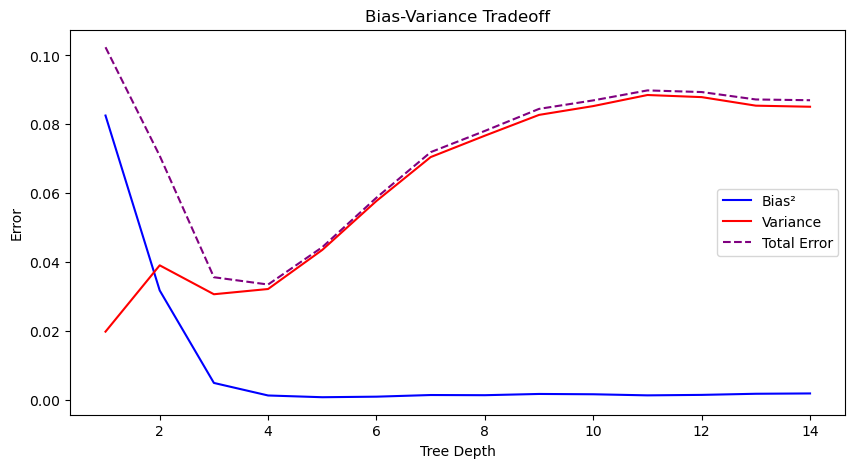

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X = np.linspace(0, 1, 100).reshape(-1, 1)
y_true = np.sin(2 * np.pi * X).ravel()

depths = range(1, 15)
bias_squared = []
variance = []
total_error = []

n_experiments = 50

for depth in depths:
    predictions = []
    for _ in range(n_experiments):
        
        y_noisy = y_true + np.random.randn(100) * 0.3
        model = DecisionTreeRegressor(max_depth=depth)
        model.fit(X, y_noisy)
        predictions.append(model.predict(X))

    predictions = np.array(predictions)
    mean_pred = predictions.mean(axis=0)

    bias_sq = np.mean((mean_pred - y_true) ** 2)
    var = np.mean(predictions.var(axis=0))

    bias_squared.append(bias_sq)
    variance.append(var)
    total_error.append(bias_sq + var)

plt.figure(figsize=(10, 5))
plt.plot(depths, bias_squared, label='Bias²', color='blue')
plt.plot(depths, variance, label='Variance', color='red')
plt.plot(depths, total_error, label='Total Error', color='purple', linestyle='--')
plt.xlabel('Tree Depth')
plt.ylabel('Error')
plt.title('Bias-Variance Tradeoff')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# From scratch K-Fold Cross Validation
def kfold_cross_validation(X, y, model, k=5):
    n = len(X)
    fold_size = n // k
    scores = []

    # shuffle indices
    indices = np.random.permutation(n)

    for fold in range(k):
        # test indices for this fold
        test_start = fold * fold_size
        test_end = test_start + fold_size
        test_indices = indices[test_start:test_end]

        # train indices are everything else
        train_indices = np.concatenate([
            indices[:test_start],
            indices[test_end:]
        ])

        X_train, X_test = X[train_indices], X[test_indices]
        y_train, y_test = y[train_indices], y[test_indices]

        model.fit(X_train, y_train)
        score = np.mean(model.predict(X_test) == y_test)
        scores.append(score)
        print(f"Fold {fold+1}: accuracy = {score:.4f}")

    print(f"\nMean accuracy: {np.mean(scores):.4f}")
    print(f"Std deviation: {np.std(scores):.4f}")
    return scores

# Run it
iris = load_iris()
X, y = iris.data, iris.target

np.random.seed(42)
model = DecisionTreeClassifier(max_depth=3)
scores = kfold_cross_validation(X, y, model, k=5)

Fold 1: accuracy = 1.0000
Fold 2: accuracy = 0.9667
Fold 3: accuracy = 0.9333
Fold 4: accuracy = 0.9000
Fold 5: accuracy = 0.9667

Mean accuracy: 0.9533
Std deviation: 0.0340


In [ ]:
from sklearn.model_selection import cross_val_score

sklearn_scores = cross_val_score(model, X, y, cv=5)
print(f"\nSklearn CV scores: {sklearn_scores}")
print(f"Sklearn mean: {sklearn_scores.mean():.4f}")
print(f"Sklearn std:  {sklearn_scores.std():.4f}")


Sklearn CV scores: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Sklearn mean: 0.9600
Sklearn std:  0.0249


In [5]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

# Breast cancer dataset - real medical data, imbalanced classes
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Class distribution:")
print(f"Malignant (0): {np.sum(y==0)}")
print(f"Benign    (1): {np.sum(y==1)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
model = DecisionTreeClassifier(max_depth=1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# All metrics
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Class distribution:
Malignant (0): 212
Benign    (1): 357

Accuracy:  0.8947
Precision: 0.9403
Recall:    0.8873
F1 Score:  0.9130

Confusion Matrix:
[[39  4]
 [ 8 63]]


In [6]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.8972
